Using device: cuda
Total samples loaded: 34165
Classes: ['A' 'B' 'C' 'D' 'E' 'F' 'G' 'H' 'I' 'J' 'K' 'L' 'M' 'N' 'O' 'P' 'Q' 'R'
 'S' 'Space' 'Stop' 'T' 'U' 'V' 'W' 'X' 'Y' 'Z']
Epoch [1/50] Train Acc: 0.9020 | Test Acc: 0.9996
Epoch [2/50] Train Acc: 0.9922 | Test Acc: 0.9987
Epoch [3/50] Train Acc: 0.9962 | Test Acc: 0.9986
Epoch [4/50] Train Acc: 0.9963 | Test Acc: 0.9998
Epoch [5/50] Train Acc: 0.9969 | Test Acc: 0.9996
Epoch [6/50] Train Acc: 0.9963 | Test Acc: 0.9993
Epoch [7/50] Train Acc: 0.9947 | Test Acc: 1.0000
Epoch [8/50] Train Acc: 0.9983 | Test Acc: 1.0000
Epoch [9/50] Train Acc: 0.9968 | Test Acc: 0.9999
Epoch [10/50] Train Acc: 0.9972 | Test Acc: 0.9995
Epoch [11/50] Train Acc: 0.9960 | Test Acc: 0.9998
Epoch [12/50] Train Acc: 0.9976 | Test Acc: 0.9999
Epoch [13/50] Train Acc: 0.9972 | Test Acc: 0.9992
Epoch [14/50] Train Acc: 0.9978 | Test Acc: 1.0000
Epoch [15/50] Train Acc: 0.9977 | Test Acc: 1.0000
Epoch [16/50] Train Acc: 0.9973 | Test Acc: 0.9994
Epoch [17/50] T

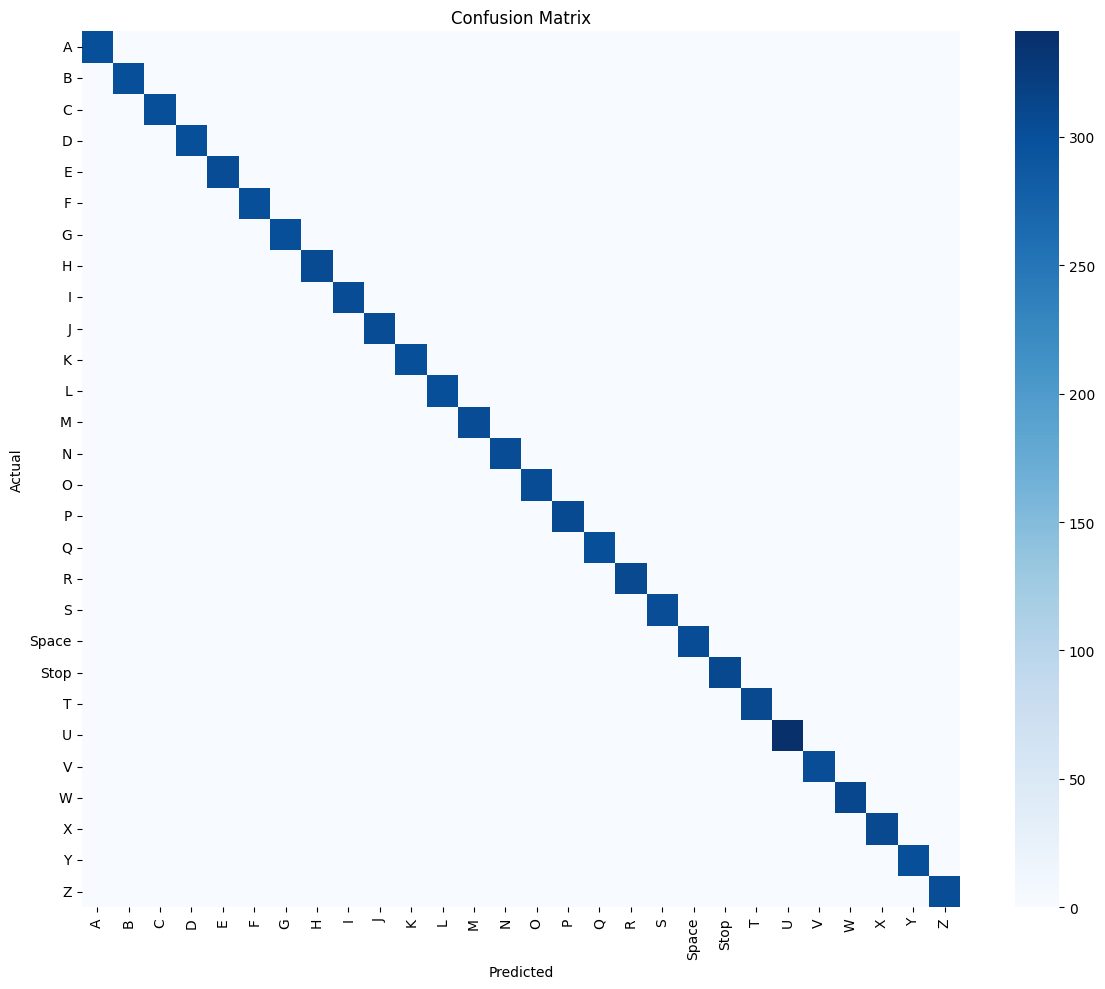

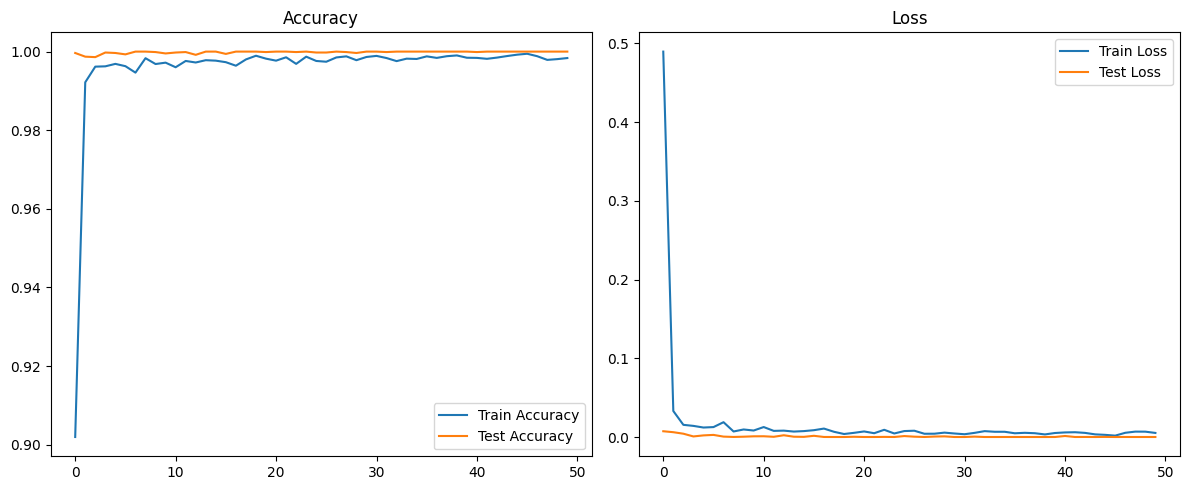


Training Complete. Model and metrics saved.


In [ ]:
import os
import json
import joblib
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
)

# ================== CONFIG ==================
DATASET_PATH = r"specify you're own dataset's" #vishnu

RUNS_DIR = r"specify you're output directory/runs/resnet_50"
os.makedirs(SAVE_DIR, exist_ok=True)

BATCH_SIZE = 64
EPOCHS = 50
LR = 0.001
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Using device:", DEVICE)

# ================== LOAD DATA ==================
X = []
y = []

class_names = sorted(os.listdir(DATASET_DIR))

for class_name in class_names:
    class_path = os.path.join(DATASET_DIR, class_name, "landmarks")

    if not os.path.isdir(class_path):
        continue

    for file in os.listdir(class_path):
        if file.endswith(".npy"):
            file_path = os.path.join(class_path, file)
            landmarks = np.load(file_path)

            if landmarks.shape[0] == 63:
                X.append(landmarks.astype(np.float32))
                y.append(class_name)

X = np.array(X)
y = np.array(y)

print("Total samples loaded:", len(X))

# ================== ENCODE LABELS ==================
le = LabelEncoder()
y_encoded = le.fit_transform(y)

NUM_CLASSES = len(le.classes_)
print("Classes:", le.classes_)

joblib.dump(le, os.path.join(SAVE_DIR, "label_encoder.pkl"))

# ================== SPLIT DATA ==================
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.25,
    random_state=42,
    stratify=y_encoded
)

# Convert to tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

# ================== DATASET CLASS ==================
class LandmarkDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_loader = DataLoader(
    LandmarkDataset(X_train, y_train),
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    LandmarkDataset(X_test, y_test),
    batch_size=BATCH_SIZE,
    shuffle=False
)

# ================== MODEL ==================
class ASL_MLP(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(63, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.net(x)

model = ASL_MLP(NUM_CLASSES).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

# ================== TRAIN LOOP ==================
best_acc = 0.0
train_acc_list = []
test_acc_list = []
train_loss_list = []
test_loss_list = []

for epoch in range(EPOCHS):
    model.train()
    train_correct = 0
    train_total = 0
    train_loss = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

    train_acc = train_correct / train_total
    train_loss /= len(train_loader)

    # ===== VALIDATION =====
    model.eval()
    test_correct = 0
    test_total = 0
    test_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            test_loss += loss.item()
            _, preds = torch.max(outputs, 1)

            test_correct += (preds == labels).sum().item()
            test_total += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    test_acc = test_correct / test_total
    test_loss /= len(test_loader)

    train_acc_list.append(train_acc)
    test_acc_list.append(test_acc)
    train_loss_list.append(train_loss)
    test_loss_list.append(test_loss)

    print(f"Epoch [{epoch+1}/{EPOCHS}] "
          f"Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f}")

    # Save best model
    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(
            model.state_dict(),
            os.path.join(SAVE_DIR, "asl_landmark_mlp_best.pth")
        )

print("\nBest Test Accuracy:", best_acc)

# ================== METRICS ==================
precision = precision_score(all_labels, all_preds, average='weighted')
recall = recall_score(all_labels, all_preds, average='weighted')
f1 = f1_score(all_labels, all_preds, average='weighted')

print("\nPrecision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

print("\nClassification Report:\n")
print(classification_report(
    all_labels,
    all_preds,
    target_names=le.classes_
))

# ================== CONFUSION MATRIX ==================
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(12,10))
sns.heatmap(cm,
            annot=False,
            cmap="Blues",
            xticklabels=le.classes_,
            yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "confusion_matrix.png"))
plt.show()

# ================== ACCURACY & LOSS GRAPHS ==================
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(train_acc_list, label="Train Accuracy")
plt.plot(test_acc_list, label="Test Accuracy")
plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(train_loss_list, label="Train Loss")
plt.plot(test_loss_list, label="Test Loss")
plt.title("Loss")
plt.legend()

plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "training_curves.png"))
plt.show()

# ================== SAVE CONFIG ==================
config = {
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "learning_rate": LR,
    "num_classes": NUM_CLASSES,
    "best_accuracy": best_acc,
    "precision": precision,
    "recall": recall,
    "f1_score": f1
}

with open(os.path.join(SAVE_DIR, "training_config.json"), "w") as f:
    json.dump(config, f, indent=4)

print("\nTraining Complete. Model and metrics saved.")